In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

adj_close    = pd.read_csv("./input/수정주가_현금배당반영.csv", index_col=0, parse_dates=True)
close        = pd.read_csv("./input/종가.csv", index_col=0, parse_dates=True)
share        = pd.read_csv("./input/상장주식수_보통주.csv", index_col=0, parse_dates=True)
pre_beta_df  = pd.read_csv("./output/pre_ranking_beta.csv", index_col=0, parse_dates=True)
mkt_returns  = pd.read_csv("./output/mkt_portfolio_ret.csv", index_col=0, parse_dates=True)
is_kospi_raw = pd.read_csv("./input/시장구분.csv", index_col=0, parse_dates=True)

---
### **Size-Beta Portfolio**

In [2]:
ME_df       = (close * share) / 1_000_000
is_kospi    = (is_kospi_raw == 'KS').astype(int)
monthly_ret = adj_close.pct_change(fill_method=None)

In [3]:
june_ends = pd.to_datetime([f"{y}-06-30" for y in range(1999, 2025 + 1)])
june_ends = june_ends.append(pd.DatetimeIndex(['2025-12-31']))
june_ends

DatetimeIndex(['1999-06-30', '2000-06-30', '2001-06-30', '2002-06-30',
               '2003-06-30', '2004-06-30', '2005-06-30', '2006-06-30',
               '2007-06-30', '2008-06-30', '2009-06-30', '2010-06-30',
               '2011-06-30', '2012-06-30', '2013-06-30', '2014-06-30',
               '2015-06-30', '2016-06-30', '2017-06-30', '2018-06-30',
               '2019-06-30', '2020-06-30', '2021-06-30', '2022-06-30',
               '2023-06-30', '2024-06-30', '2025-06-30', '2025-12-31'],
              dtype='datetime64[ns]', freq=None)

In [4]:
assign_list    = []
port_ret_list  = []
port_char_list = []

for i in range(len(june_ends) - 1):
    start_date = june_ends[i]
    end_date   = june_ends[i + 1]

    # 1) 6월말 기준 원자료
    ME_t       = ME_df.loc[start_date]
    pre_beta_t = pre_beta_df.loc[start_date]
    is_kospi_t = is_kospi.loc[start_date]

    # 2) size breakpoint: pre_beta 유무와 무관하게 전체 KOSPI 종목 사용
    ME_kospi_all = ME_t[is_kospi_t == 1].dropna()
    size_breaks  = ME_kospi_all.quantile(np.arange(0.1, 1.0, 0.1)).values

    # 3) 분류 대상: ME와 pre_beta가 모두 있는 종목
    df = pd.DataFrame({
        'ME': ME_t,
        'pre_beta': pre_beta_t,
        'is_kospi': is_kospi_t
    }).dropna(subset=['ME', 'pre_beta']).copy()

    # 4) size decile 부여
    df['size_decile'] = pd.cut(
        df['ME'],
        bins=[-np.inf, *size_breaks, np.inf],
        labels=range(1, 11)
    )

    # 5) 각 size decile 내에서 KOSPI 종목만으로 pre_beta breakpoint 계산
    df['pre_beta_decile'] = np.nan

    for s in range(1, 11):
        kospi_in_size = df.loc[(df['size_decile'] == s) & (df['is_kospi'] == 1), 'pre_beta']
        beta_breaks = kospi_in_size.quantile(np.arange(0.1, 1.0, 0.1)).values

        mask = df['size_decile'] == s
        df.loc[mask, 'pre_beta_decile'] = pd.cut(
            df.loc[mask, 'pre_beta'],
            bins=[-np.inf, *beta_breaks, np.inf],
            labels=range(1, 11)
        ).astype(float)

    df = df.dropna(subset=['size_decile', 'pre_beta_decile']).copy()
    df['size_decile'] = df['size_decile'].astype(int)
    df['pre_beta_decile'] = df['pre_beta_decile'].astype(int)

    # 추가: 종목별 포트폴리오 배정 저장
    assign = (
        df.reset_index()
          .rename(columns={'index': 'Ticker'})
    )
    assign['Date'] = end_date
    assign_list.append(assign[['Date', 'Ticker', 'ME', 'pre_beta', 'is_kospi', 'size_decile', 'pre_beta_decile']])

    # 6) 보유기간 월별 수익률
    ret_window = monthly_ret.loc[start_date:end_date, df.index][1:]

    # 7) 포트폴리오별 월별 평균수익률 저장
    port_ret = (
        ret_window.T
        .join(df[['size_decile', 'pre_beta_decile']])
        .groupby(['size_decile', 'pre_beta_decile'])
        .mean()
        .T
        .stack([0, 1])
        .rename('ret')
        .reset_index()
        .rename(columns={'level_0': 'Date'})
    )
    port_ret_list.append(port_ret)

    # 8) start_date 기준 포트폴리오 특성치 저장
    port_char = (
        df.groupby(['size_decile', 'pre_beta_decile'])
          .agg(
              n_firms=('ME', 'size'),
              mean_lnME=('ME', lambda x: np.log(x).mean()),
              mean_pre_beta=('pre_beta', 'mean')
          )
          .reset_index()
    )
    port_char['Date'] = start_date
    port_char_list.append(port_char)

portfolio_assignment = pd.concat(assign_list, ignore_index=True)
portfolio_ret        = pd.concat(port_ret_list, ignore_index=True)
portfolio_chars      = pd.concat(port_char_list, ignore_index=True)

In [5]:
portfolio_chars.to_csv("./output/size_beta_portfolio_characteristics.csv")
portfolio_ret.to_csv("./output/size_beta_portfolio_returns.csv")

---
### **Table I - Panel A**

In [6]:
# (1) 10x10 포트폴리오 wide
portfolio_ret_wide = (
    portfolio_ret
    .pivot(index='Date', columns=['size_decile', 'pre_beta_decile'], values='ret')
    .reindex(columns=pd.MultiIndex.from_product([range(1, 11), range(1, 11)]))
)

# (2) size별 전체 평균 (각 size 안에서 beta 1~10 평균)
size_all = {
    f'(Size {i}, ALL)': portfolio_ret_wide.loc[:, [(i, j) for j in range(1, 11)]].mean(axis=1)
    for i in range(1, 11)
}

# (3) beta별 전체 평균 (각 beta 안에서 size 1~10 평균)
beta_all = {
    f'(ALL, Beta {j})': portfolio_ret_wide.loc[:, [(i, j) for i in range(1, 11)]].mean(axis=1)
    for j in range(1, 11)
}

# (4) 전체 평균
all_all = pd.Series(
    portfolio_ret_wide.mean(axis=1),
    index=portfolio_ret_wide.index,
    name='(ALL, ALL)'
)

# (5) 기존 100개 컬럼 이름 변경
portfolio_ret_wide.columns = [f'({i}, {j})' for i, j in portfolio_ret_wide.columns]

# (6) 20개 + 1개 추가
portfolio_ret_wide = pd.concat(
    [
        portfolio_ret_wide,
        pd.DataFrame(size_all, index=portfolio_ret_wide.index),
        pd.DataFrame(beta_all, index=portfolio_ret_wide.index),
        all_all
    ],
    axis=1
)

In [7]:
portfolio_ret_mean = pd.DataFrame(
    index=['ALL'] + [f'Size {i}' for i in range(1, 11)],
    columns=['ALL'] + [f'Beta {j}' for j in range(1, 11)],
    dtype=float
)

# 10x10 셀
for i in range(1, 11):
    for j in range(1, 11):
        portfolio_ret_mean.loc[f'Size {i}', f'Beta {j}'] = portfolio_ret_wide[f'({i}, {j})'].mean()

# 각 size별 ALL 열
for i in range(1, 11):
    portfolio_ret_mean.loc[f'Size {i}', 'ALL'] = portfolio_ret_wide[f'(Size {i}, ALL)'].mean()

# 각 beta별 ALL 행
for j in range(1, 11):
    portfolio_ret_mean.loc['ALL', f'Beta {j}'] = portfolio_ret_wide[f'(ALL, Beta {j})'].mean()

# 전체 ALL
portfolio_ret_mean.loc['ALL', 'ALL'] = portfolio_ret_wide['(ALL, ALL)'].mean()

print("Size-Beta Portfolio Mean Returns:")
round(portfolio_ret_mean * 100, 2)

Size-Beta Portfolio Mean Returns:


,ALL,Beta 1,Beta 2,Beta 3,Beta 4,Beta 5,Beta 6,Beta 7,Beta 8,Beta 9,Beta 10
ALL,1.07,1.04,1.07,1.26,1.17,1.29,1.18,1.02,1.20,0.75,0.72
Size 1,2.52,2.75,2.69,2.46,2.29,2.98,2.25,2.21,3.10,1.77,2.75
Size 2,1.57,1.74,1.77,2.27,1.40,1.83,1.55,1.41,1.43,1.10,1.19
Size 3,1.10,0.86,1.08,1.20,0.98,1.85,1.63,1.12,0.86,0.65,0.76
Size 4,0.94,0.74,0.50,1.20,0.77,1.21,1.16,1.34,1.53,0.54,0.42
Size 5,0.85,0.62,0.99,1.14,1.15,1.00,1.28,0.83,0.48,0.90,0.13
Size 6,0.71,0.63,0.97,1.14,0.71,0.70,0.89,0.38,0.55,0.56,0.58
Size 7,0.55,0.59,0.93,0.75,0.78,0.60,0.70,-0.05,0.69,0.33,0.20
Size 8,0.69,0.71,0.56,0.86,1.50,0.25,0.57,1.04,1.00,0.49,-0.11
Size 9,0.82,0.26,0.50,0.92,1.04,1.24,0.67,0.96,1.28,0.70,0.65


<Axes: title={'center': 'Average Return by Size Decile'}, ylabel='Average Return'>

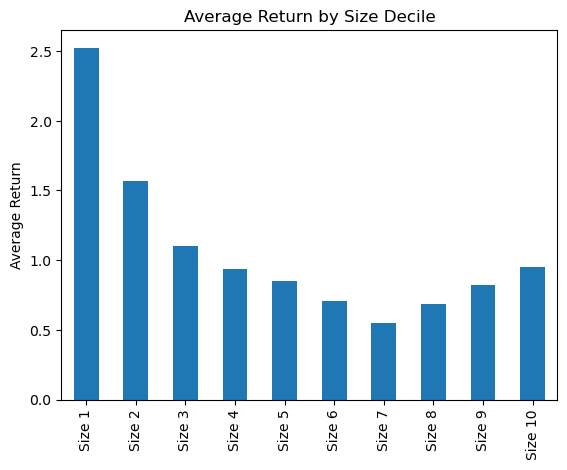

In [8]:
(portfolio_ret_mean['ALL'].iloc[1:] * 100).plot(kind='bar', title='Average Return by Size Decile', ylabel='Average Return')

<Axes: title={'center': 'Average Return by Beta Decile (All Size Deciles)'}, ylabel='Average Return'>

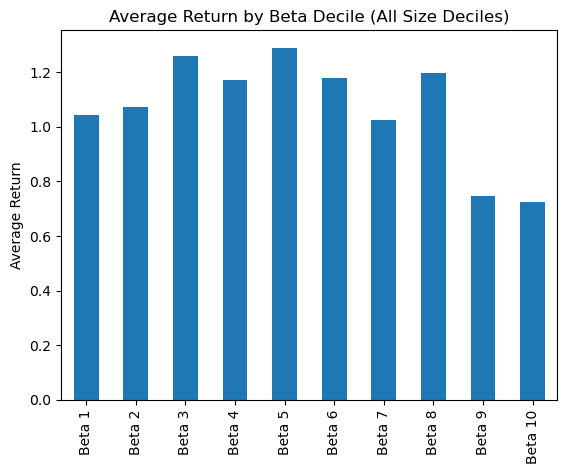

In [9]:
(portfolio_ret_mean.loc['ALL'].iloc[1:] * 100).plot(kind='bar', title='Average Return by Beta Decile (All Size Deciles)', ylabel='Average Return')

---
### **Table I - Panel B**

In [10]:
import pandas as pd
import statsmodels.api as sm

# 종속변수
y = portfolio_ret_wide['(Size 1, ALL)'].rename('ret')

# 설명변수
X = pd.concat([
    mkt_returns['MKT'].rename('mkt_t'),
    mkt_returns['MKT'].shift(1).rename('mkt_t_1')
], axis=1)

# y와 X를 날짜 기준으로 맞춘 뒤 결측 제거
df = pd.concat([y, X], axis=1).dropna()

# 상수항 추가
X_reg = sm.add_constant(df[['mkt_t', 'mkt_t_1']])
y_reg = df['ret']

# 회귀
res = sm.OLS(y_reg, X_reg).fit()

# 결과 출력
# print(res.summary())

# post-beta = beta_t + beta_t-1
print("post-beta:", res.params['mkt_t'] + res.params['mkt_t_1'])

post-beta: 0.5944844644289166


In [11]:
import statsmodels.api as sm

X = sm.add_constant(pd.concat([
    mkt_returns['MKT'].rename('mkt_t'),
    mkt_returns['MKT'].shift(1).rename('mkt_t_1')
], axis=1).loc[portfolio_ret_wide.index])

# 각 컬럼별로 직접 post-beta 추정
post_beta = portfolio_ret_wide.apply(
    lambda y: sm.OLS(y, X, missing='drop').fit().params[['mkt_t', 'mkt_t_1']].sum()
)

# 출력 테이블 생성
post_beta_table = pd.DataFrame(
    index=['ALL'] + [f'Size {i}' for i in range(1, 11)],
    columns=['ALL'] + [f'Beta {j}' for j in range(1, 11)],
    dtype=float
)

# 10x10 셀
for i in range(1, 11):
    for j in range(1, 11):
        post_beta_table.loc[f'Size {i}', f'Beta {j}'] = post_beta[f'({i}, {j})']

# 각 size별 ALL 열
for i in range(1, 11):
    post_beta_table.loc[f'Size {i}', 'ALL'] = post_beta[f'(Size {i}, ALL)']

# 각 beta별 ALL 행
for j in range(1, 11):
    post_beta_table.loc['ALL', f'Beta {j}'] = post_beta[f'(ALL, Beta {j})']

# 전체 ALL
post_beta_table.loc['ALL', 'ALL'] = post_beta['(ALL, ALL)']

print("Size-Beta Portfolio Post-Beta Estimates:")
round(post_beta_table, 2)

Size-Beta Portfolio Post-Beta Estimates:


,ALL,Beta 1,Beta 2,Beta 3,Beta 4,Beta 5,Beta 6,Beta 7,Beta 8,Beta 9,Beta 10
ALL,0.84,0.70,0.66,0.79,0.81,0.79,0.88,0.84,0.93,0.98,1.00
Size 1,0.59,0.33,0.56,0.68,0.60,0.50,0.84,0.63,0.71,0.60,0.49
Size 2,0.69,0.61,0.55,0.62,0.77,0.56,0.70,0.69,0.83,0.81,0.78
Size 3,0.71,0.65,0.73,0.57,0.73,0.83,0.56,0.66,0.87,0.72,0.77
Size 4,0.80,0.60,0.67,0.72,0.75,0.75,0.80,0.83,0.98,0.95,0.93
Size 5,0.82,0.71,0.58,0.85,0.72,0.66,0.87,0.90,0.93,0.99,0.96
Size 6,0.83,0.71,0.79,0.78,0.84,0.70,0.75,0.88,0.86,1.01,0.95
Size 7,0.89,0.77,0.76,0.91,0.88,0.86,0.92,0.73,1.00,0.96,1.10
Size 8,0.98,0.86,0.68,0.87,0.97,0.91,1.10,1.03,1.00,1.21,1.18
Size 9,0.99,0.73,0.60,0.82,0.86,1.04,1.08,0.98,1.13,1.26,1.37


<Axes: title={'center': 'Post-Beta by Size Decile'}, ylabel='Post-Beta Estimate'>

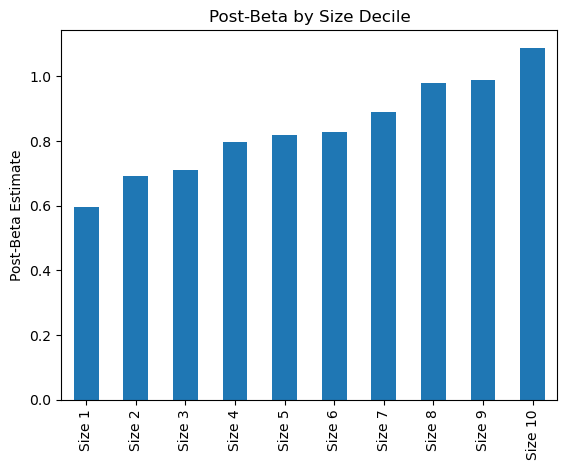

In [12]:
post_beta_table['ALL'].iloc[1:].plot(kind='bar', title='Post-Beta by Size Decile', ylabel='Post-Beta Estimate')

<Axes: title={'center': 'Post-Beta by Beta Decile (All Size Deciles)'}, ylabel='Post-Beta Estimate'>

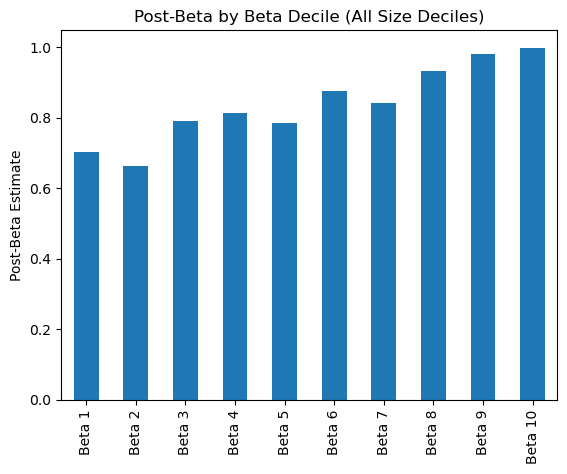

In [13]:
post_beta_table.loc['ALL'].iloc[1:].plot(kind='bar', title='Post-Beta by Beta Decile (All Size Deciles)', ylabel='Post-Beta Estimate')

---
### **Table I - Panel C**

In [14]:
def make_10x10_table(x):
    out = pd.DataFrame(
        index=['ALL'] + [f'Size {i}' for i in range(1, 11)],
        columns=['ALL'] + [f'Beta {j}' for j in range(1, 11)],
        dtype=float
    )
    
    cell_mean = x.groupby([portfolio_chars['size_decile'], portfolio_chars['pre_beta_decile']]).mean()
    size_mean = x.groupby(portfolio_chars['size_decile']).mean()
    beta_mean = x.groupby(portfolio_chars['pre_beta_decile']).mean()
    
    for i in range(1, 11):
        for j in range(1, 11):
            out.loc[f'Size {i}', f'Beta {j}'] = cell_mean.loc[(i, j)]
        out.loc[f'Size {i}', 'ALL'] = size_mean.loc[i]
    
    for j in range(1, 11):
        out.loc['ALL', f'Beta {j}'] = beta_mean.loc[j]
    
    out.loc['ALL', 'ALL'] = x.mean()
    
    return out

n_firms_mean       = make_10x10_table(portfolio_chars['n_firms'])
mean_lnME_mean     = make_10x10_table(portfolio_chars['mean_lnME'])
mean_pre_beta_mean = make_10x10_table(portfolio_chars['mean_pre_beta'])

In [15]:
print("Average Log(ME) in Each Portfolio:")
round(mean_lnME_mean, 2)

Average Log(ME) in Each Portfolio:


,ALL,Beta 1,Beta 2,Beta 3,Beta 4,Beta 5,Beta 6,Beta 7,Beta 8,Beta 9,Beta 10
ALL,11.97,11.95,11.99,11.97,11.98,11.97,11.99,11.99,11.96,11.96,11.94
Size 1,9.73,9.67,9.72,9.72,9.75,9.73,9.79,9.77,9.73,9.69,9.71
Size 2,10.44,10.44,10.44,10.46,10.43,10.44,10.44,10.43,10.44,10.44,10.44
Size 3,10.82,10.82,10.82,10.82,10.83,10.81,10.83,10.82,10.82,10.81,10.82
Size 4,11.16,11.16,11.16,11.17,11.16,11.16,11.16,11.16,11.15,11.16,11.17
Size 5,11.49,11.49,11.51,11.49,11.49,11.48,11.49,11.49,11.49,11.49,11.50
Size 6,11.84,11.84,11.85,11.83,11.84,11.84,11.85,11.85,11.86,11.84,11.84
Size 7,12.27,12.27,12.28,12.28,12.28,12.27,12.27,12.27,12.27,12.28,12.27
Size 8,12.85,12.85,12.85,12.87,12.85,12.84,12.84,12.84,12.83,12.85,12.84
Size 9,13.71,13.71,13.70,13.70,13.69,13.71,13.70,13.78,13.70,13.69,13.67


<Axes: title={'center': 'Average Log(ME) by Beta Decile'}, ylabel='Average Log(ME)'>

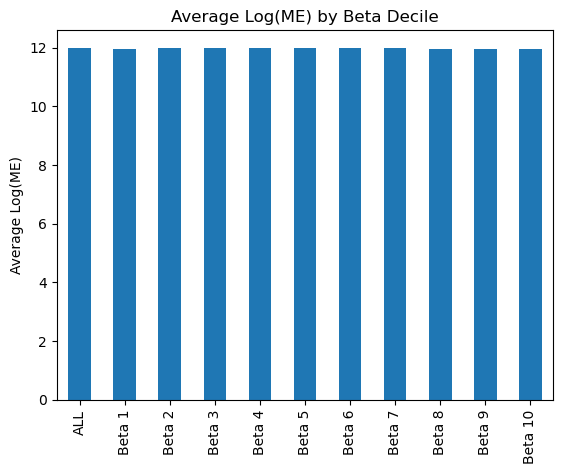

In [16]:
mean_lnME_mean.loc['ALL'].plot(kind='bar', title='Average Log(ME) by Beta Decile', ylabel='Average Log(ME)')

<Axes: title={'center': 'Average Log(ME) by Size Decile'}, ylabel='Average Log(ME)'>

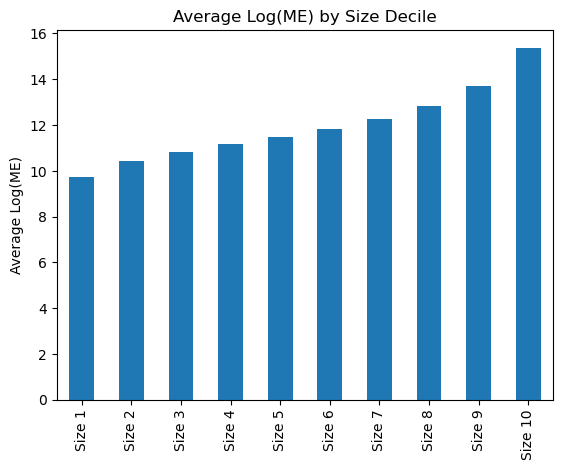

In [17]:
mean_lnME_mean['ALL'].iloc[1:].plot(kind='bar', title='Average Log(ME) by Size Decile', ylabel='Average Log(ME)')

---
### **Table I - Average Number of Firms in Each Portfolio**

In [18]:
print("Average Number of Firms in Each Portfolio:")
round(n_firms_mean, 2)

Average Number of Firms in Each Portfolio:


,ALL,Beta 1,Beta 2,Beta 3,Beta 4,Beta 5,Beta 6,Beta 7,Beta 8,Beta 9,Beta 10
ALL,15.45,19.46,13.30,13.07,12.68,13.45,13.55,14.61,15.45,15.95,22.98
Size 1,31.23,36.81,26.04,28.44,23.22,27.41,28.07,32.52,32.44,32.52,44.81
Size 2,23.40,32.15,22.59,15.74,18.52,21.93,20.07,20.85,21.33,24.04,36.81
Size 3,18.81,24.11,15.96,16.26,15.48,16.26,15.00,16.67,19.85,19.44,29.07
Size 4,16.82,22.00,13.67,15.30,15.48,13.56,15.15,14.85,15.15,17.26,25.78
Size 5,14.76,20.78,11.63,11.96,12.19,12.15,12.30,14.85,14.81,14.56,22.37
Size 6,13.24,16.48,11.15,11.11,10.04,10.44,11.89,12.30,13.11,14.11,21.81
Size 7,11.56,14.44,10.04,9.41,8.70,10.04,9.85,10.63,12.78,12.00,17.67
Size 8,9.99,12.07,8.07,8.48,8.93,8.48,9.15,9.37,10.44,11.04,13.81
Size 9,7.94,8.30,7.41,7.44,7.48,7.52,7.63,7.74,8.15,8.11,9.67


---
### **Table I - Average Pre-Beta in Each Portfolio**

In [19]:
print("Average Pre-Beta in Each Portfolio:")
round(mean_pre_beta_mean, 2)

Average Pre-Beta in Each Portfolio:


,ALL,Beta 1,Beta 2,Beta 3,Beta 4,Beta 5,Beta 6,Beta 7,Beta 8,Beta 9,Beta 10
ALL,1.01,-0.03,0.47,0.65,0.79,0.92,1.05,1.19,1.35,1.57,2.17
Size 1,0.95,-0.20,0.37,0.58,0.74,0.87,0.99,1.15,1.33,1.55,2.15
Size 2,0.99,-0.10,0.48,0.65,0.77,0.90,1.03,1.16,1.31,1.53,2.14
Size 3,1.01,-0.05,0.48,0.67,0.80,0.93,1.05,1.17,1.34,1.56,2.15
Size 4,1.02,-0.05,0.47,0.66,0.82,0.94,1.05,1.18,1.35,1.56,2.22
Size 5,1.04,-0.04,0.51,0.67,0.81,0.94,1.07,1.19,1.37,1.60,2.25
Size 6,1.00,-0.01,0.47,0.64,0.78,0.91,1.03,1.16,1.32,1.53,2.16
Size 7,0.99,-0.04,0.46,0.62,0.75,0.89,1.02,1.16,1.32,1.56,2.17
Size 8,1.03,0.04,0.47,0.65,0.79,0.92,1.04,1.19,1.36,1.61,2.21
Size 9,1.06,0.09,0.48,0.68,0.82,0.96,1.10,1.25,1.41,1.63,2.23


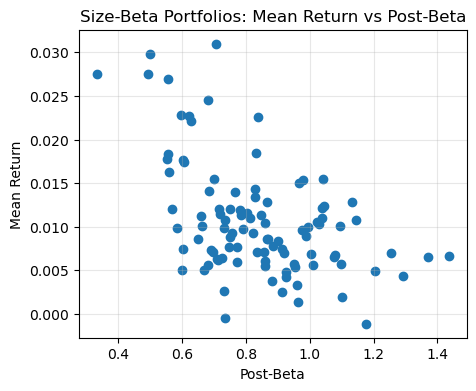

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# ALL 행/열 제외
x = post_beta_table.drop(index='ALL', columns='ALL')
y = portfolio_ret_mean.drop(index='ALL', columns='ALL')

# 10x10 값을 1차원으로 펼치기
plot_df = pd.DataFrame({
    'pre_beta': x.to_numpy().ravel(),
    'mean_return': y.to_numpy().ravel()
})

# 산점도
plt.figure(figsize=(5, 4))
plt.scatter(plot_df['pre_beta'], plot_df['mean_return'])
plt.xlabel('Post-Beta')
plt.ylabel('Mean Return')
plt.title('Size-Beta Portfolios: Mean Return vs Post-Beta')
plt.grid(True, alpha=0.3)
plt.show()

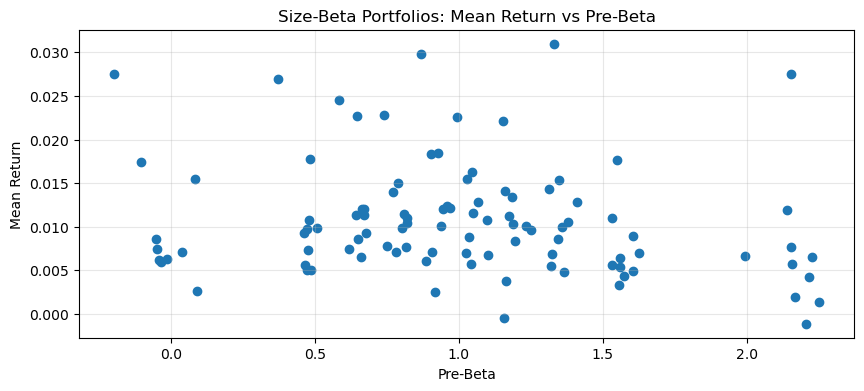

In [21]:
# ALL 행/열 제외
x = mean_pre_beta_mean.drop(index='ALL', columns='ALL')
y = portfolio_ret_mean.drop(index='ALL', columns='ALL')

# 10x10 값을 1차원으로 펼치기
plot_df = pd.DataFrame({
    'pre_beta': x.to_numpy().ravel(),
    'mean_return': y.to_numpy().ravel()
})

# 산점도
plt.figure(figsize=(10, 4))
plt.scatter(plot_df['pre_beta'], plot_df['mean_return'])
plt.xlabel('Pre-Beta')
plt.ylabel('Mean Return')
plt.title('Size-Beta Portfolios: Mean Return vs Pre-Beta')
plt.grid(True, alpha=0.3)
plt.show()

<Axes: title={'center': 'Average Pre-Beta by Size Decile'}, ylabel='Average Pre-Beta'>

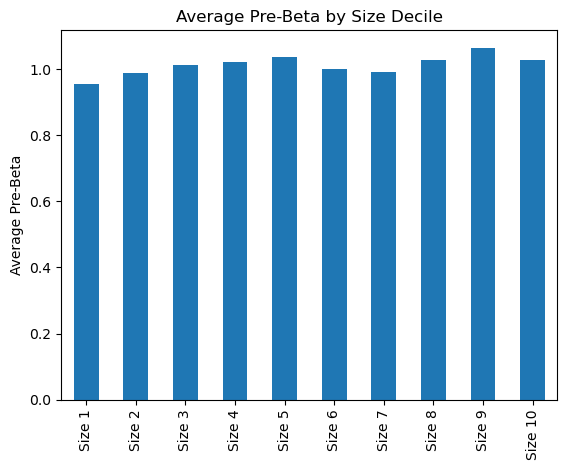

In [22]:
mean_pre_beta_mean['ALL'].iloc[1:].plot(kind='bar', title='Average Pre-Beta by Size Decile', ylabel='Average Pre-Beta')

---
### **Panel Data**

**Post Beta**

In [23]:
post_beta_map = post_beta[post_beta.index.str.match(r'^\(\d+,\s*\d+\)$')]
post_beta_map.index = pd.MultiIndex.from_tuples(
    post_beta_map.index.str.extract(r'^\((\d+),\s*(\d+)\)$').astype(int).itertuples(index=False, name=None),
    names=['size_decile', 'pre_beta_decile']
)

portfolio_assignment['post_beta'] = pd.MultiIndex.from_frame(
    portfolio_assignment[['size_decile', 'pre_beta_decile']]
).map(post_beta_map)

**ln(ME)**

In [24]:
lnME_map = (
    np.log(ME_df.loc[june_ends].shift(1).iloc[1:])
    .stack()
    .rename('lnME')
    .reset_index()
    .rename(columns={'level_0': 'Date', 'level_1': 'Ticker'})
)

portfolio_assignment = portfolio_assignment.merge(lnME_map, on=['Date', 'Ticker'], how='left')

**ln(BE/ME)**

In [25]:
equity_consolidated = pd.read_csv("./input/자본총계_지배_연결.csv", index_col=0, parse_dates=True)
equity_separate     = pd.read_csv("./input/자본총계_지배_주재무제표.csv", index_col=0, parse_dates=True)

# 음수 자본은 NaN으로 처리
equity_consolidated = equity_consolidated.applymap(lambda x: x if x >= 0 else np.nan)
equity_separate     = equity_separate.applymap(lambda x: x if x >= 0 else np.nan)

In [26]:
ln_BE_ME = np.log((equity_consolidated * 1000) / ME_df.loc[equity_consolidated.index]).iloc[:-2]

ln_BE_ME_june = ln_BE_ME.copy()
ln_BE_ME_june.index = ln_BE_ME_june.index + pd.offsets.MonthEnd(6)

ln_BE_ME_june.loc[pd.Timestamp('2025-12-31')] = np.nan
ln_BE_ME_june = ln_BE_ME_june.sort_index()

In [27]:
ln_BE_ME_map = (
    ln_BE_ME_june.shift(1).iloc[1:]
    .stack()
    .rename('ln_BE_ME_con')
    .reset_index()
    .rename(columns={'level_0': 'Date', 'level_1': 'Ticker'})
)

portfolio_assignment = portfolio_assignment.merge(ln_BE_ME_map, on=['Date', 'Ticker'], how='left')

In [28]:
ln_BE_ME_sep = np.log((equity_separate * 1000) / ME_df.loc[equity_separate.index]).iloc[:-2]

ln_BE_ME_sep_june = ln_BE_ME_sep.copy()
ln_BE_ME_sep_june.index = ln_BE_ME_sep_june.index + pd.offsets.MonthEnd(6)

ln_BE_ME_sep_june.loc[pd.Timestamp('2025-12-31')] = np.nan
ln_BE_ME_sep_june = ln_BE_ME_sep_june.sort_index()

In [29]:
ln_BE_ME_map_sep = (
    ln_BE_ME_sep_june.shift(1).iloc[1:]
    .stack()
    .rename('ln_BE_ME_sep')
    .reset_index()
    .rename(columns={'level_0': 'Date', 'level_1': 'Ticker'})
)

portfolio_assignment = portfolio_assignment.merge(ln_BE_ME_map_sep, on=['Date', 'Ticker'], how='left')

**ln(A/ME)**

In [30]:
A_consolidated = pd.read_csv("./input/자산총계_연결.csv", index_col=0, parse_dates=True)
A_separate     = pd.read_csv("./input/자산총계_주재무제표.csv", index_col=0, parse_dates=True)

In [31]:
ln_A_ME = np.log(A_consolidated * 1000 / ME_df.loc[A_consolidated.index]).iloc[:-2]

ln_A_ME_june = ln_A_ME.copy()
ln_A_ME_june.index = ln_A_ME_june.index + pd.offsets.MonthEnd(6)

ln_A_ME_june.loc[pd.Timestamp('2025-12-31')] = np.nan
ln_A_ME_june = ln_A_ME_june.sort_index()

In [32]:
ln_A_ME_map = (
    ln_A_ME_june.shift(1).iloc[1:]
    .stack()
    .rename('ln_A_ME_con')
    .reset_index()
    .rename(columns={'level_0': 'Date', 'level_1': 'Ticker'})
)

portfolio_assignment = portfolio_assignment.merge(ln_A_ME_map, on=['Date', 'Ticker'], how='left')

In [33]:
ln_A_ME_sep = np.log(A_separate * 1000 / ME_df.loc[A_separate.index]).iloc[:-2]

ln_A_ME_sep_june = ln_A_ME_sep.copy()
ln_A_ME_sep_june.index = ln_A_ME_sep_june.index + pd.offsets.MonthEnd(6)

ln_A_ME_sep_june.loc[pd.Timestamp('2025-12-31')] = np.nan
ln_A_ME_sep_june = ln_A_ME_sep_june.sort_index()

In [34]:
ln_A_ME_map_sep = (
    ln_A_ME_sep_june.shift(1).iloc[1:]
    .stack()
    .rename('ln_A_ME_sep')
    .reset_index()
    .rename(columns={'level_0': 'Date', 'level_1': 'Ticker'})
)

portfolio_assignment = portfolio_assignment.merge(ln_A_ME_map_sep, on=['Date', 'Ticker'], how='left')

**ln(A/BE)**

In [35]:
ln_A_BE = np.log((A_consolidated * 1000) / (equity_consolidated * 1000)).iloc[:-2]

ln_A_BE_june = ln_A_BE.copy()
ln_A_BE_june.index = ln_A_BE_june.index + pd.offsets.MonthEnd(6)

ln_A_BE_june.loc[pd.Timestamp('2025-12-31')] = np.nan
ln_A_BE_june = ln_A_BE_june.sort_index()

In [36]:
ln_A_BE_map = (
    ln_A_BE_june.shift(1).iloc[1:]
    .stack()
    .rename('ln_A_BE_con')
    .reset_index()
    .rename(columns={'level_0': 'Date', 'level_1': 'Ticker'})
)

portfolio_assignment = portfolio_assignment.merge(ln_A_BE_map, on=['Date', 'Ticker'], how='left')

In [37]:
ln_A_BE_sep = np.log((A_separate * 1000) / (equity_separate * 1000)).iloc[:-2]

ln_A_BE_sep_june = ln_A_BE_sep.copy()
ln_A_BE_sep_june.index = ln_A_BE_sep_june.index + pd.offsets.MonthEnd(6)

ln_A_BE_sep_june.loc[pd.Timestamp('2025-12-31')] = np.nan
ln_A_BE_sep_june = ln_A_BE_sep_june.sort_index()

In [38]:
ln_A_BE_map_sep = (
    ln_A_BE_sep_june.shift(1).iloc[1:]
    .stack()
    .rename('ln_A_BE_sep')
    .reset_index()
    .rename(columns={'level_0': 'Date', 'level_1': 'Ticker'})
)

portfolio_assignment = portfolio_assignment.merge(ln_A_BE_map_sep, on=['Date', 'Ticker'], how='left')

**E/P**

In [39]:
E_consolidated = pd.read_csv("./input/당기순이익_지배_연결.csv", index_col=0, parse_dates=True)
E_separate     = pd.read_csv("./input/당기순이익_지배_주재무제표.csv", index_col=0, parse_dates=True)

In [40]:
E_consolidated_dummy = (E_consolidated <= 0).where(E_consolidated.notna()).astype('float')
E_separate_dummy     = (E_separate <= 0).where(E_separate.notna()).astype('float')

# E_consolidated_dummy = E_consolidated_dummy.replace({True: 1, False: 0})
# E_separate_dummy     = E_separate_dummy.replace({True: 1, False: 0})

In [41]:
E_consolidated = E_consolidated.clip(lower=0)
E_separate     = E_separate.clip(lower=0)

In [42]:
E_P = ((E_consolidated / 1000) / ME_df.loc[E_consolidated.index]).iloc[:-1]

E_P_june = E_P.copy()
E_P_june.index = E_P_june.index + pd.offsets.MonthEnd(6)

E_P_june.loc[pd.Timestamp('2025-12-31')] = np.nan
E_P_june = E_P_june.sort_index()

In [43]:
E_P_map = (
    E_P_june.shift(1).iloc[1:]
    .stack()
    .rename('E_P_con')
    .reset_index()
    .rename(columns={'level_0': 'Date', 'level_1': 'Ticker'})
)

portfolio_assignment = portfolio_assignment.merge(E_P_map, on=['Date', 'Ticker'], how='left')

In [44]:
E_P_sep = ((E_separate / 1000) / ME_df.loc[E_separate.index]).iloc[:-2]

E_P_sep_june = E_P_sep.copy()
E_P_sep_june.index = E_P_sep_june.index + pd.offsets.MonthEnd(6)

E_P_sep_june.loc[pd.Timestamp('2025-12-31')] = np.nan
E_P_sep_june = E_P_sep_june.sort_index()

In [45]:
E_P_map_sep = (
    E_P_sep_june.shift(1).iloc[1:]
    .stack()
    .rename('E_P_sep')
    .reset_index()
    .rename(columns={'level_0': 'Date', 'level_1': 'Ticker'})
)

portfolio_assignment = portfolio_assignment.merge(E_P_map_sep, on=['Date', 'Ticker'], how='left')

In [46]:
E_P_dummy_june = E_consolidated_dummy.iloc[:-1].copy()
E_P_dummy_june.index = E_P_dummy_june.index + pd.offsets.MonthEnd(6)

E_P_dummy_june.loc[pd.Timestamp('2025-12-31')] = np.nan
E_P_dummy_june = E_P_dummy_june.sort_index()

In [47]:
E_P_dummy_map = (
    E_P_dummy_june.shift(1).iloc[1:]
    .stack()
    .rename('E_P_dummy_con')
    .reset_index()
    .rename(columns={'level_0': 'Date', 'level_1': 'Ticker'})
)

portfolio_assignment = portfolio_assignment.merge(E_P_dummy_map, on=['Date', 'Ticker'], how='left')

In [48]:
E_P_dummy_sep_june = E_separate_dummy.iloc[:-2].copy()
E_P_dummy_sep_june.index = E_P_dummy_sep_june.index + pd.offsets.MonthEnd(6)

E_P_dummy_sep_june.loc[pd.Timestamp('2025-12-31')] = np.nan
E_P_dummy_sep_june = E_P_dummy_sep_june.sort_index()

In [49]:
E_P_dummy_map_sep = (
    E_P_dummy_sep_june.shift(1).iloc[1:]
    .stack()
    .rename('E_P_dummy_sep')
    .reset_index()
    .rename(columns={'level_0': 'Date', 'level_1': 'Ticker'})
)

portfolio_assignment = portfolio_assignment.merge(E_P_dummy_map_sep, on=['Date', 'Ticker'], how='left')

In [50]:
portfolio_assignment.to_csv("./output/panel_data.csv", index=False)

In [51]:
portfolio_assignment

,Date,Ticker,ME,pre_beta,is_kospi,size_decile,pre_beta_decile,post_beta,lnME,ln_BE_ME_con,ln_BE_ME_sep,ln_A_ME_con,ln_A_ME_sep,ln_A_BE_con,ln_A_BE_sep,E_P_con,E_P_sep,E_P_dummy_con,E_P_dummy_sep
0,2000-06-30,A000020,111617.200000,1.736924,1,8,10,1.177398,11.622830,NaN,14.574711,NaN,15.389850,NaN,0.815138,NaN,0.376411,NaN,0.0
1,2000-06-30,A000040,12727.723080,1.647066,1,3,8,0.868751,9.451538,NaN,15.102826,NaN,17.158993,NaN,2.056167,NaN,0.000000,NaN,1.0
2,2000-06-30,A000050,50222.403000,0.995273,1,6,4,0.835405,10.824216,NaN,14.454162,NaN,15.851584,NaN,1.397422,NaN,0.148739,NaN,0.0
3,2000-06-30,A000070,226291.429200,1.179603,1,9,5,1.044325,12.329579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-06-30,A000080,68478.854300,1.307215,1,7,7,0.733633,11.134280,NaN,15.304480,NaN,17.870818,NaN,2.566338,NaN,0.000000,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41712,2025-12-31,A950170,356532.337720,0.675594,0,6,5,0.695986,12.784180,13.688394,13.688394,14.359520,14.359520,0.671126,0.671126,0.371266,0.371266,0.0,0.0
41713,2025-12-31,A950190,131081.784130,0.749745,0,4,4,0.748162,11.783577,14.073859,14.073859,14.290478,14.290478,0.216619,0.216619,0.071740,0.071740,0.0,0.0
41714,2025-12-31,A950200,73674.082990,0.132040,0,2,1,0.606231,11.207406,12.886341,12.886341,13.475237,13.475237,0.588897,0.588897,0.000000,0.000000,1.0,1.0
41715,2025-12-31,A950210,883413.478500,1.448315,1,8,8,0.995176,13.691549,13.022825,13.022825,13.618470,13.618470,0.595645,0.595645,0.024555,0.024555,0.0,0.0
